# Laboratorio 05 - Clasificación Multiclase

### Dataset: MNIST-M

**Estudiante:** Emily Karen Villarpando Olmedo

Clasificación de dígitos manuscritos del 0 al 9 mediante regresión logística One-vs-All.

##1. Importaciones y Google Drive

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##2. Cargar el dataset con Pandas

In [ ]:
ruta = '/content/drive/MyDrive/Inteligencia Artificial 1 - Karen/Laboratorios/Laboratorio 05/'

train = pd.read_parquet(ruta + 'train-00000-of-00001-571b6b1e2c195186.parquet')
test = pd.read_parquet(ruta + 'test-00000-of-00001-ba3ad971b105ff65.parquet')

# Unimos ambos archivos para aplicar nuestra propia división 80/20
df = pd.concat([train, test], ignore_index=True)

print("Cantidad total de ejemplos:", len(df))
print("Columnas:", df.columns.tolist())

df.head()

Cantidad total de ejemplos: 68002
Columnas: ['image', 'label']


,image,label
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0


##3. Distribución de clases

In [ ]:
print(df['label'].value_counts().sort_index())

label
0    6703
1    7656
2    6786
3    6936
4    6636
5    6138
6    6668
7    7072
8    6637
9    6770
Name: count, dtype: int64


## 4. Balanceo del Dataset

Para garantizar una cantidad uniforme de ejemplos por clase, se toma como referencia la clase con menor cantidad de imágenes.

In [ ]:
minimo = df['label'].value_counts().min()

df_balanceado = pd.concat([
    grupo.sample(n=minimo, random_state=42)
    for _, grupo in df.groupby('label')
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Total después del balanceo:", len(df_balanceado))
print(df_balanceado['label'].value_counts().sort_index())

Total después del balanceo: 61380
label
0    6138
1    6138
2    6138
3    6138
4    6138
5    6138
6    6138
7    6138
8    6138
9    6138
Name: count, dtype: int64


##5. Comprobación de las Imágenes

Antes de transformar las 61 mil imágenes, probemos solamente una para confirmar cómo viene almacenada y su resolución.

Resolución: (32, 32)
Etiqueta: 9


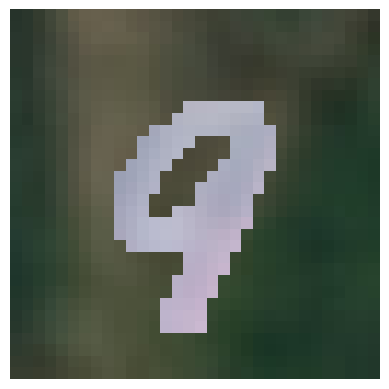

In [ ]:
from PIL import Image
import io

def cargar_imagen(dato):
    return Image.open(io.BytesIO(dato['bytes']))

imagen = cargar_imagen(df_balanceado.iloc[0]['image'])

print("Resolución:", imagen.size)
print("Etiqueta:", df_balanceado.iloc[0]['label'])

plt.imshow(imagen)
plt.axis('off')
plt.show()

## 6. Preprocesamiento y Normalización

Las imágenes se convierten a escala de grises, se normalizan y se transforman en vectores para ser utilizadas por el modelo de regresión logística.
Posteriormente, el dataset se divide en 80% para entrenamiento y 20% para prueba.

In [43]:
def procesar_imagen(dato):
    img = Image.open(io.BytesIO(dato['bytes'])).convert('L')

    # Recorte central: 32x32 -> 28x28
    img = img.crop((2, 2, 30, 30))

    # Vectorización y normalización
    return np.asarray(img, dtype=np.float32).flatten() / 255.0

X = np.array(
    [procesar_imagen(img) for img in df_balanceado['image']],
    dtype=np.float32
)

y = df_balanceado['label'].to_numpy()

print("X:", X.shape)
print("y:", y.shape)

X: (61380, 784)
y: (61380,)


### 6.1 Visualización de las Imágenes Procesadas

Se muestra un ejemplo de cada una de las 10 clases después del preprocesamiento y normalización.

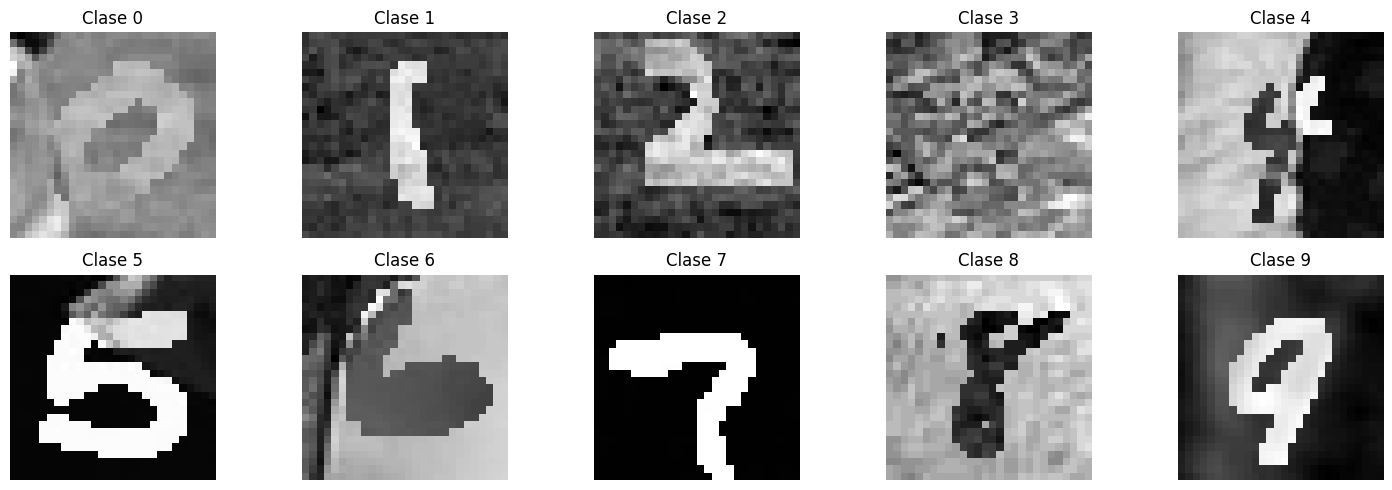

In [45]:
# Visualizar un ejemplo procesado de cada clase

plt.figure(figsize=(15, 5))

for clase in range(10):

    # Buscar la primera imagen perteneciente a esta clase
    indice = np.where(y == clase)[0][0]

    # Reconstruir los 784 valores como imagen 28x28
    imagen = X[indice].reshape(28, 28)

    plt.subplot(2, 5, clase + 1)
    plt.imshow(imagen, cmap='gray')
    plt.title(f'Clase {clase}')
    plt.axis('off')

plt.tight_layout()
plt.show()

##7. División del Dataset

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Prueba:", X_test.shape, y_test.shape)

Entrenamiento: (49104, 784) (49104,)
Prueba: (12276, 784) (12276,)


## 8. Regresión Logística

Se define la función sigmoide utilizada para calcular las probabilidades del modelo.

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

## 9. Función de Costo

Se calcula el costo y el gradiente de la regresión logística aplicando regularización.

In [ ]:
def lrCostFunction(theta, X, y, lambda_):
    m = len(y)

    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-9, 1 - 1e-9)

    J = (-1 / m) * np.sum(
        y * np.log(h) + (1 - y) * np.log(1 - h)
    )

    J += (lambda_ / (2 * m)) * np.sum(theta[1:] ** 2)

    grad = (1 / m) * X.T.dot(h - y)
    grad[1:] += (lambda_ / m) * theta[1:]

    return J, grad

## 10. Clasificación One-vs-All

Se entrenan 10 clasificadores de regresión logística, uno para cada dígito del 0 al 9.

In [ ]:
from scipy import optimize

def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape

    all_theta = np.zeros((num_labels, n + 1))

    X = np.concatenate([
        np.ones((m, 1)),
        X
    ], axis=1)

    for c in range(num_labels):

        initial_theta = np.zeros(n + 1)

        resultado = optimize.minimize(
            lrCostFunction,
            initial_theta,
            args=(X, (y == c).astype(int), lambda_),
            jac=True,
            method='CG',
            options={'maxiter': 50}
        )

        all_theta[c] = resultado.x

        print(
            f"Clase {c} entrenada - "
            f"Costo: {resultado.fun:.4f}"
        )

    return all_theta

##11. Entrenamiento

In [ ]:
num_labels = 10
lambda_ = 0.1

all_theta = oneVsAll(
    X_train,
    y_train,
    num_labels,
    lambda_
)

Clase 0 entrenada - Costo: 0.2964
Clase 1 entrenada - Costo: 0.2986
Clase 2 entrenada - Costo: 0.3061
Clase 3 entrenada - Costo: 0.3067
Clase 4 entrenada - Costo: 0.3033
Clase 5 entrenada - Costo: 0.3096
Clase 6 entrenada - Costo: 0.2990
Clase 7 entrenada - Costo: 0.3031
Clase 8 entrenada - Costo: 0.3108
Clase 9 entrenada - Costo: 0.3092


## 12. Predicción One-vs-All

Para cada imagen se calcula la probabilidad de pertenecer a cada una de las 10 clases. Se selecciona como predicción la clase con mayor probabilidad.

In [ ]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]

    X = np.concatenate([
        np.ones((m, 1)),
        X
    ], axis=1)

    probabilidades = sigmoid(X.dot(all_theta.T))
    return np.argmax(probabilidades, axis=1)

##13. Precisión del modelo

In [ ]:
pred_train = predictOneVsAll(all_theta, X_train)
pred_test = predictOneVsAll(all_theta, X_test)

precision_train = np.mean(pred_train == y_train) * 100
precision_test = np.mean(pred_test == y_test) * 100

print(f"Precisión de entrenamiento: {precision_train:.2f}%")
print(f"Precisión de prueba: {precision_test:.2f}%")

Precisión de entrenamiento: 46.27%
Precisión de prueba: 44.84%


## 14. Gráfica de Precisión

Se compara la precisión obtenida con los datos de entrenamiento y con el conjunto de prueba.

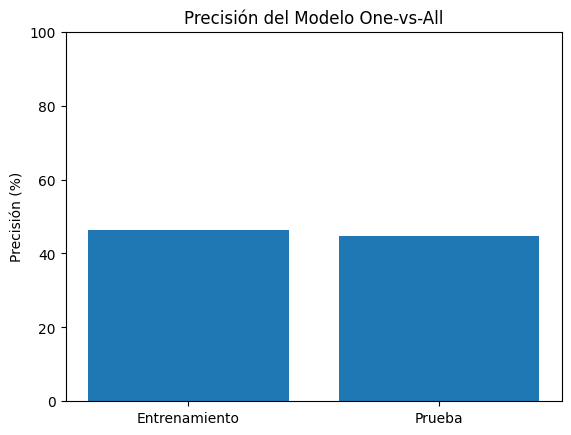

In [ ]:
plt.bar(
    ['Entrenamiento', 'Prueba'],
    [precision_train, precision_test]
)

plt.ylabel('Precisión (%)')
plt.title('Precisión del Modelo One-vs-All')
plt.ylim(0, 100)

plt.show()

## 15. Gráfica de costo

Podemos calcular el costo final de cada uno de los 10 clasificadores usando los theta que ya entrenamos, sin volver a entrenar nada:

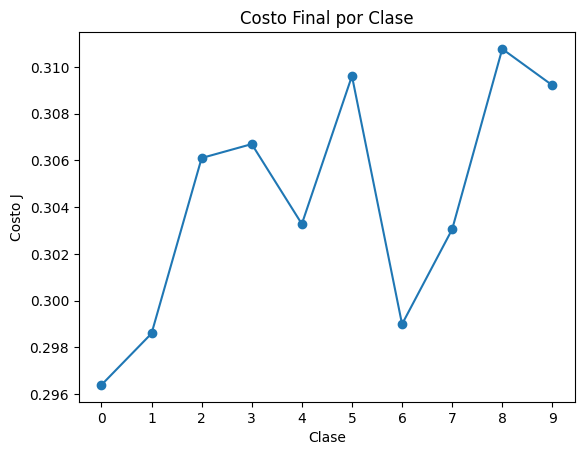

In [ ]:
X_train_bias = np.concatenate([
    np.ones((X_train.shape[0], 1)),
    X_train
], axis=1)

costos = []

for clase in range(num_labels):
    y_binaria = (y_train == clase).astype(int)

    costo, _ = lrCostFunction(
        all_theta[clase],
        X_train_bias,
        y_binaria,
        lambda_
    )

    costos.append(costo)

plt.plot(range(10), costos, marker='o')
plt.xlabel('Clase')
plt.ylabel('Costo J')
plt.title('Costo Final por Clase')
plt.xticks(range(10))
plt.show()

## 16. Predicciones

Se muestran algunos ejemplos del conjunto de prueba junto con su etiqueta real y la predicción realizada por el modelo.

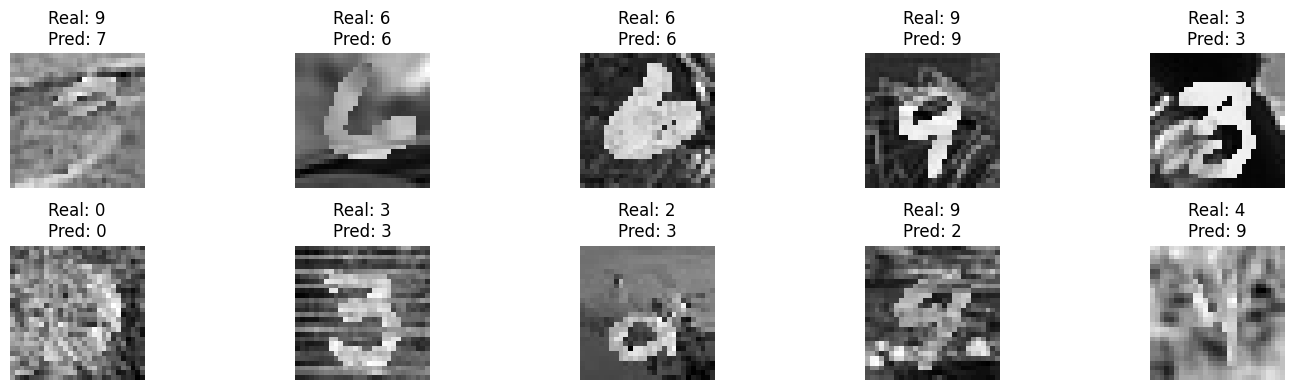

In [ ]:
indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(15, 4))

for i, indice in enumerate(indices):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test[indice].reshape(28, 28),
        cmap='gray'
    )

    plt.title(
        f"Real: {y_test[indice]}\nPred: {pred_test[indice]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

## 17. Conclusión

Se implementó un modelo de clasificación multiclase One-vs-All utilizando regresión logística sobre el dataset MNIST-M. El conjunto de datos fue balanceado y dividido en 80% para entrenamiento y 20% para prueba.

El modelo obtuvo una precisión de 46.27% en entrenamiento y 44.84% en prueba. La menor precisión respecto a MNIST tradicional se relaciona con la mayor complejidad de MNIST-M, debido a que los dígitos se encuentran sobre fondos de imágenes reales.